In [26]:
import os
import glob
import time
import re
from pathlib import Path
import numpy as np
import google.generativeai as genai
from google.api_core.exceptions import ResourceExhausted

In [28]:
# Load precomputed workload embeddings and filenames
import numpy as np
from pathlib import Path

project_root = Path("/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering")
embeddings_path = project_root / "workload_embeddings.npy"
processed_files_path = project_root / "processed_files.txt"

embeddings = np.load(embeddings_path)
with processed_files_path.open() as f:
    filenames = [line.strip() for line in f if line.strip()]

print(f"Loaded embeddings shape: {embeddings.shape}")
print(f"Loaded {len(filenames)} filenames")
if embeddings.shape[0] != len(filenames):
    print("WARNING: number of embeddings does not match number of filenames")

Loaded embeddings shape: (1275, 768)
Loaded 1275 filenames


In [29]:
import umap
import hdbscan
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# 1) Normalize embeddings
scaler = StandardScaler()
X = scaler.fit_transform(embeddings)

best_score = -1
best_result = None

n_neighbors_list = [5, 10, 20, 50]
min_dist_list = [0.0, 0.05, 0.1, 0.3]
umap_metrics = ['cosine', 'euclidean']
min_cluster_sizes = [2, 3, 4,  5, 6, 7, 8, 9, 10, 11,12,13,14,15]
min_samples_list = [1, 5]
selection_methods = ['leaf', 'eom']

for nn in n_neighbors_list:
    for md in min_dist_list:
        for um_metric in umap_metrics:
            reducer = umap.UMAP(
                n_neighbors=nn,
                min_dist=md,
                metric=um_metric,
                n_components=5,
                random_state=42
            )
            X_reduced = reducer.fit_transform(X)

            for mcs in min_cluster_sizes:
                for ms in min_samples_list:
                    for sel in selection_methods:
                        clusterer = hdbscan.HDBSCAN(
                            min_cluster_size=mcs,
                            min_samples=ms,
                            cluster_selection_method=sel,
                            metric='euclidean'
                        )
                        labels = clusterer.fit_predict(X_reduced)

                        valid_mask = labels != -1
                        if np.sum(valid_mask) < 2 or len(set(labels[valid_mask])) < 2:
                            continue

                        sil = silhouette_score(X_reduced[valid_mask], labels[valid_mask])

                        if sil > best_score:
                            best_score = sil
                            db = davies_bouldin_score(X_reduced[valid_mask], labels[valid_mask])
                            ch = calinski_harabasz_score(X_reduced[valid_mask], labels[valid_mask])
                            best_result = {
                                "X_reduced": X_reduced,
                                "labels": labels,
                                "sil": sil,
                                "db": db,
                                "ch": ch,
                                "params": {
                                    "n_neighbors": nn,
                                    "min_dist": md,
                                    "umap_metric": um_metric,
                                    "min_cluster_size": mcs,
                                    "min_samples": ms,
                                    "selection": sel,
                                },
                            }

print("Best params:", best_result["params"])
print(
    f"Metrics -> Silhouette: {best_result['sil']:.3f} | "
    f"Davies-Bouldin: {best_result['db']:.3f} | "
    f"Calinski-Harabasz: {best_result['ch']:.1f}"
)

X_reduced = best_result["X_reduced"]
labels = best_result["labels"]

# Create DataFrame
df = pd.DataFrame({'workload': filenames, 'cluster_id': labels})
df.head(10)

/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packa

Best params: {'n_neighbors': 50, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 2, 'min_samples': 5, 'selection': 'eom'}
Metrics -> Silhouette: 0.836 | Davies-Bouldin: 0.241 | Calinski-Harabasz: 26538.5


,workload,cluster_id
0,job_0.wg,0
1,job_1.wg,0
2,job_10.wg,0
3,job_100.wg,0
4,job_101.wg,0
5,job_102.wg,0
6,job_103.wg,0
7,job_104.wg,0
8,job_105.wg,0
9,job_106.wg,0


In [30]:
# Extract benchmark name from workload (e.g., "job_0.wg" -> "job")
df_with_benchmark = df.copy()
df_with_benchmark["benchmark"] = df_with_benchmark["workload"].str.extract(r"^([^_]+)")

# Print unique benchmarks in each cluster
for cluster_id, benchmarks in (
    df_with_benchmark.groupby("cluster_id")["benchmark"]
    .unique()
    .sort_index()
    .items()
):
    print(f"Cluster {cluster_id}: {sorted(benchmarks.tolist())}")

Cluster 0: ['job']
Cluster 1: ['tpcds']
Cluster 2: ['ssb', 'tpcds']
Cluster 3: ['ssb', 'tpch']


/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


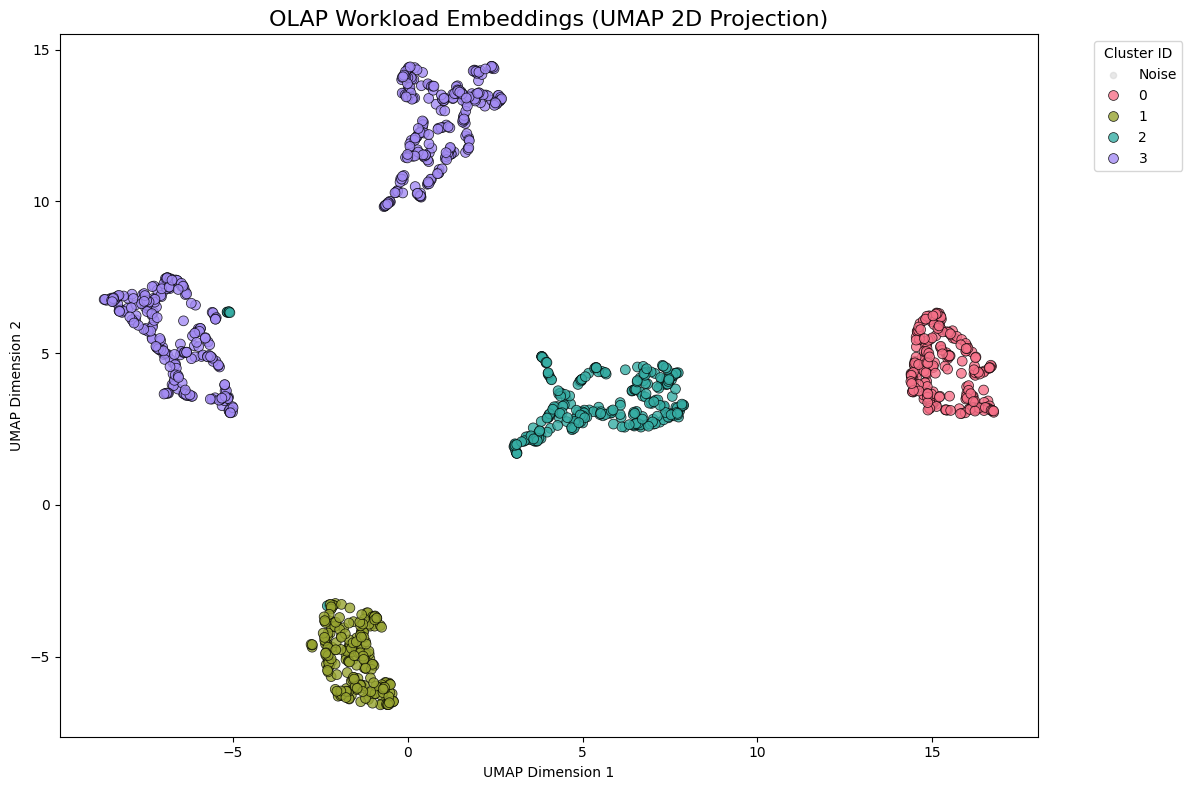

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2D projection strictly for visualization
visual_mapper = umap.UMAP(n_neighbors=5, min_dist=0.05, metric='cosine', n_components=2, random_state=42)
X_2d = visual_mapper.fit_transform(embeddings)

# Prepare plot
plt.figure(figsize=(12, 8))
palette = sns.color_palette('husl', len(set(labels)) - (1 if -1 in labels else 0))

# Plot noise (-1) in light grey
noise_mask = labels == -1
plt.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c='lightgrey', s=20, alpha=0.5, label='Noise')

# Plot clusters
clustered_mask = labels != -1
sns.scatterplot(
    x=X_2d[clustered_mask, 0], 
    y=X_2d[clustered_mask, 1],
    hue=labels[clustered_mask],
    palette=palette,
    s=50,
    edgecolor='k',
    alpha=0.8,
    legend='full'
)

plt.title("OLAP Workload Embeddings (UMAP 2D Projection)", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster ID")
plt.tight_layout()
plt.show()

In [47]:
import re
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ── Build a DataFrame linking each filename → its embedding index & benchmark ──
filenames_arr = np.array(filenames)
benchmark_names = np.array([re.match(r"^(ssb_flat|ssb|[^_]+)", fn).group(1) for fn in filenames_arr])
unique_benchmarks = sorted(set(benchmark_names))
print(f"Benchmarks found: {unique_benchmarks}\n")

per_benchmark_results = {}

for bm in unique_benchmarks:
    idx = np.where(benchmark_names == bm)[0]
    if len(idx) < 5:
        print(f"[{bm}]  skipped — only {len(idx)} workloads (need ≥ 5)\n")
        continue

    bm_embeddings = embeddings[idx]
    bm_filenames  = filenames_arr[idx]

    # FIX 1: Use MinMaxScaler to preserve positive geometric relationships
    X_bm = MinMaxScaler().fit_transform(bm_embeddings)

    # FIX 2: Highly Optimized Search Space
    n_neighbors_list   = [5, 10, 20, min(50, len(idx) - 1)]
    min_dist_list      = [0.0] # UMAP should pack tight for HDBSCAN
    umap_metrics       = ['cosine'] # Cosine handles sparse workload features best
    min_cluster_sizes  = list(range(2, min(15, len(idx) // 2) + 1))
    min_samples_list   = [1, 2, 5]
    selection_methods  = ['leaf', 'eom']
    n_components       = min(5, len(idx) - 1)

    best_score  = -1
    best_res_bm = None

    for nn in n_neighbors_list:
        if nn >= len(idx):
            continue
        for md in min_dist_list:
            for um_metric in umap_metrics:
                reducer = umap.UMAP(
                    n_neighbors=nn, min_dist=md, metric=um_metric,
                    n_components=n_components, random_state=42
                )
                X_red = reducer.fit_transform(X_bm)

                for mcs in min_cluster_sizes:
                    for ms in min_samples_list:
                        for sel in selection_methods:
                            clusterer = hdbscan.HDBSCAN(
                                min_cluster_size=mcs, min_samples=ms,
                                cluster_selection_method=sel, metric='euclidean'
                            )
                            lbl = clusterer.fit_predict(X_red)
                            
                            # Filter noise for valid metric calculation
                            vm  = lbl != -1
                            n_valid_clusters = len(set(lbl[vm]))
                            
                            if np.sum(vm) < 2 or n_valid_clusters < 2:
                                continue
                            
                            # FIX 3: Evaluate on ORIGINAL space (X_bm), not UMAP space (X_red)
                            sil = silhouette_score(X_bm[vm], lbl[vm], metric='cosine')
                            
                            # FIX 4: Penalize clustering that throws everything into noise
                            noise_ratio = np.sum(lbl == -1) / len(lbl)
                            penalized_sil = sil * (1.0 - noise_ratio)

                            if penalized_sil > best_score:
                                best_score = penalized_sil
                                best_res_bm = {
                                    "X_red": X_red, 
                                    "labels": lbl,
                                    "sil": sil,
                                    "penalized_sil": penalized_sil,
                                    "db":  davies_bouldin_score(X_bm[vm], lbl[vm]),
                                    "ch":  calinski_harabasz_score(X_bm[vm], lbl[vm]),
                                    "params": dict(
                                        n_neighbors=nn, min_dist=md, umap_metric=um_metric,
                                        min_cluster_size=mcs, min_samples=ms, selection=sel
                                    ),
                                    "filenames": bm_filenames,
                                    "idx": idx,
                                }

    if best_res_bm is None:
        print(f"[{bm}]  no valid clustering found — all runs produced < 2 clusters\n")
        continue

    per_benchmark_results[bm] = best_res_bm
    lbl    = best_res_bm["labels"]
    n_cls  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise  = int(np.sum(lbl == -1))
    print(f"[{bm}]  workloads={len(idx)}  clusters={n_cls}  noise={noise}")
    print(f"         params : {best_res_bm['params']}")
    print(f"         metrics: Sil={best_res_bm['sil']:.3f} (Penalized: {best_res_bm['penalized_sil']:.3f})  DB={best_res_bm['db']:.3f}\n")

print("Done.")

Benchmarks found: [np.str_('job'), np.str_('ssb'), np.str_('ssb_flat'), np.str_('tpcds'), np.str_('tpch')]



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[job]  workloads=244  clusters=6  noise=61
         params : {'n_neighbors': 20, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 9, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.202 (Penalized: 0.151)  DB=2.163



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[ssb]  workloads=240  clusters=2  noise=0
         params : {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 15, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.201 (Penalized: 0.201)  DB=1.683



...

[ssb_flat]  workloads=286  clusters=4  noise=32
         params : {'n_neighbors': 20, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 12, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.193 (Penalized: 0.172)  DB=2.041



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[tpcds]  workloads=233  clusters=2  noise=12
         params : {'n_neighbors': 20, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 13, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.253 (Penalized: 0.240)  DB=2.199



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[tpch]  workloads=272  clusters=6  noise=14
         params : {'n_neighbors': 10, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 13, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.166 (Penalized: 0.158)  DB=2.302

Done.


In [48]:

# ── Per-benchmark cluster membership table ─────────────────────────────────────
rows = []
for bm, res in per_benchmark_results.items():
    lbl = res["labels"]
    fns = res["filenames"]
    for fn, cl in zip(fns, lbl):
        rows.append({"benchmark": bm, "workload": fn, "cluster_id": int(cl)})

df_per_bm = pd.DataFrame(rows).sort_values(["benchmark", "cluster_id", "workload"]).reset_index(drop=True)

# Summary counts
summary = (
    df_per_bm.groupby(["benchmark", "cluster_id"])
    .size()
    .reset_index(name="count")
)
print(summary.to_string(index=False))


benchmark  cluster_id  count
      job          -1     61
      job           0     23
      job           1     44
      job           2     18
      job           3     23
      job           4     34
      job           5     41
      ssb           0     27
      ssb           1    213
 ssb_flat          -1     32
 ssb_flat           0     14
 ssb_flat           1     62
 ssb_flat           2    120
 ssb_flat           3     58
    tpcds          -1     12
    tpcds           0     89
    tpcds           1    132
     tpch          -1     14
     tpch           0     51
     tpch           1     23
     tpch           2     37
     tpch           3     20
     tpch           4     56
     tpch           5     71


In [50]:
import re
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ── Build a DataFrame linking each filename → its embedding index & benchmark ──
filenames_arr = np.array(filenames)
benchmark_names = np.array([re.match(r"^(ssb_flat|ssb|[^_]+)", fn).group(1) for fn in filenames_arr])
unique_benchmarks = sorted(set(benchmark_names))
print(f"Benchmarks found: {unique_benchmarks}\n")

per_benchmark_results = {}

for bm in unique_benchmarks:
    idx = np.where(benchmark_names == bm)[0]
    if len(idx) < 5:
        print(f"[{bm}]  skipped — only {len(idx)} workloads (need ≥ 5)\n")
        continue

    bm_embeddings = embeddings[idx]
    bm_filenames  = filenames_arr[idx]

    # FIX 1: Use MinMaxScaler to preserve positive geometric relationships
    X_bm = MinMaxScaler().fit_transform(bm_embeddings)

    # Highly Optimized Search Space
    n_neighbors_list   = [5, 10, 20, min(50, len(idx) - 1)]
    min_dist_list      = [0.0] 
    umap_metrics       = ['cosine'] 
    min_cluster_sizes  = list(range(2, min(15, len(idx) // 2) + 1))
    min_samples_list   = [1, 2, 5]
    selection_methods  = ['leaf', 'eom']
    n_components       = min(5, len(idx) - 1)

    best_score  = -1
    best_res_bm = None

    for nn in n_neighbors_list:
        if nn >= len(idx):
            continue
        for md in min_dist_list:
            for um_metric in umap_metrics:
                reducer = umap.UMAP(
                    n_neighbors=nn, min_dist=md, metric=um_metric,
                    n_components=n_components, random_state=42
                )
                X_red = reducer.fit_transform(X_bm)

                for mcs in min_cluster_sizes:
                    for ms in min_samples_list:
                        for sel in selection_methods:
                            clusterer = hdbscan.HDBSCAN(
                                min_cluster_size=mcs, min_samples=ms,
                                cluster_selection_method=sel, metric='euclidean'
                            )
                            lbl = clusterer.fit_predict(X_red)
                            
                            # Filter noise for valid metric calculation
                            vm  = lbl != -1
                            n_valid_clusters = len(set(lbl[vm]))
                            
                            if np.sum(vm) < 2 or n_valid_clusters < 2:
                                continue
                            
                            # THE FIX: Calculate the percentage of noise
                            noise_ratio = np.sum(lbl == -1) / len(lbl)
                            
                            # THE FIX: Hard cap on noise. Reject if more than 15% noise.
                            if noise_ratio > 0.15:
                                continue
                                
                            # If it passes the noise check, evaluate on ORIGINAL space (X_bm)
                            sil = silhouette_score(X_bm[vm], lbl[vm], metric='cosine')
                            penalized_sil = sil * (1.0 - noise_ratio)

                            if penalized_sil > best_score:
                                best_score = penalized_sil
                                best_res_bm = {
                                    "X_red": X_red, 
                                    "labels": lbl,
                                    "sil": sil,
                                    "penalized_sil": penalized_sil,
                                    "db":  davies_bouldin_score(X_bm[vm], lbl[vm]),
                                    "ch":  calinski_harabasz_score(X_bm[vm], lbl[vm]),
                                    "params": dict(
                                        n_neighbors=nn, min_dist=md, umap_metric=um_metric,
                                        min_cluster_size=mcs, min_samples=ms, selection=sel
                                    ),
                                    "filenames": bm_filenames,
                                    "idx": idx,
                                }

    if best_res_bm is None:
        print(f"[{bm}]  no valid clustering found under 15% noise limit\n")
        continue

    per_benchmark_results[bm] = best_res_bm
    lbl    = best_res_bm["labels"]
    n_cls  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise  = int(np.sum(lbl == -1))
    print(f"[{bm}]  workloads={len(idx)}  clusters={n_cls}  noise={noise}")
    print(f"         params : {best_res_bm['params']}")
    print(f"         metrics: Sil={best_res_bm['sil']:.3f} (Penalized: {best_res_bm['penalized_sil']:.3f})  DB={best_res_bm['db']:.3f}\n")

print("Done.")

Benchmarks found: [np.str_('job'), np.str_('ssb'), np.str_('ssb_flat'), np.str_('tpcds'), np.str_('tpch')]



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[job]  workloads=244  clusters=4  noise=0
         params : {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 15, 'min_samples': 1, 'selection': 'eom'}
         metrics: Sil=0.148 (Penalized: 0.148)  DB=2.378



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[ssb]  workloads=240  clusters=2  noise=0
         params : {'n_neighbors': 5, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 15, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.201 (Penalized: 0.201)  DB=1.683



...

[ssb_flat]  workloads=286  clusters=4  noise=32
         params : {'n_neighbors': 20, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 12, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.193 (Penalized: 0.172)  DB=2.041



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[tpcds]  workloads=233  clusters=2  noise=12
         params : {'n_neighbors': 20, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 13, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.253 (Penalized: 0.240)  DB=2.199



/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[tpch]  workloads=272  clusters=6  noise=14
         params : {'n_neighbors': 10, 'min_dist': 0.0, 'umap_metric': 'cosine', 'min_cluster_size': 13, 'min_samples': 5, 'selection': 'eom'}
         metrics: Sil=0.166 (Penalized: 0.158)  DB=2.302

Done.


/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/nisith/Desktop/FYP/E2ETune-AI4DB/workload_clustering/clustering/lib/python3.11/site-packa

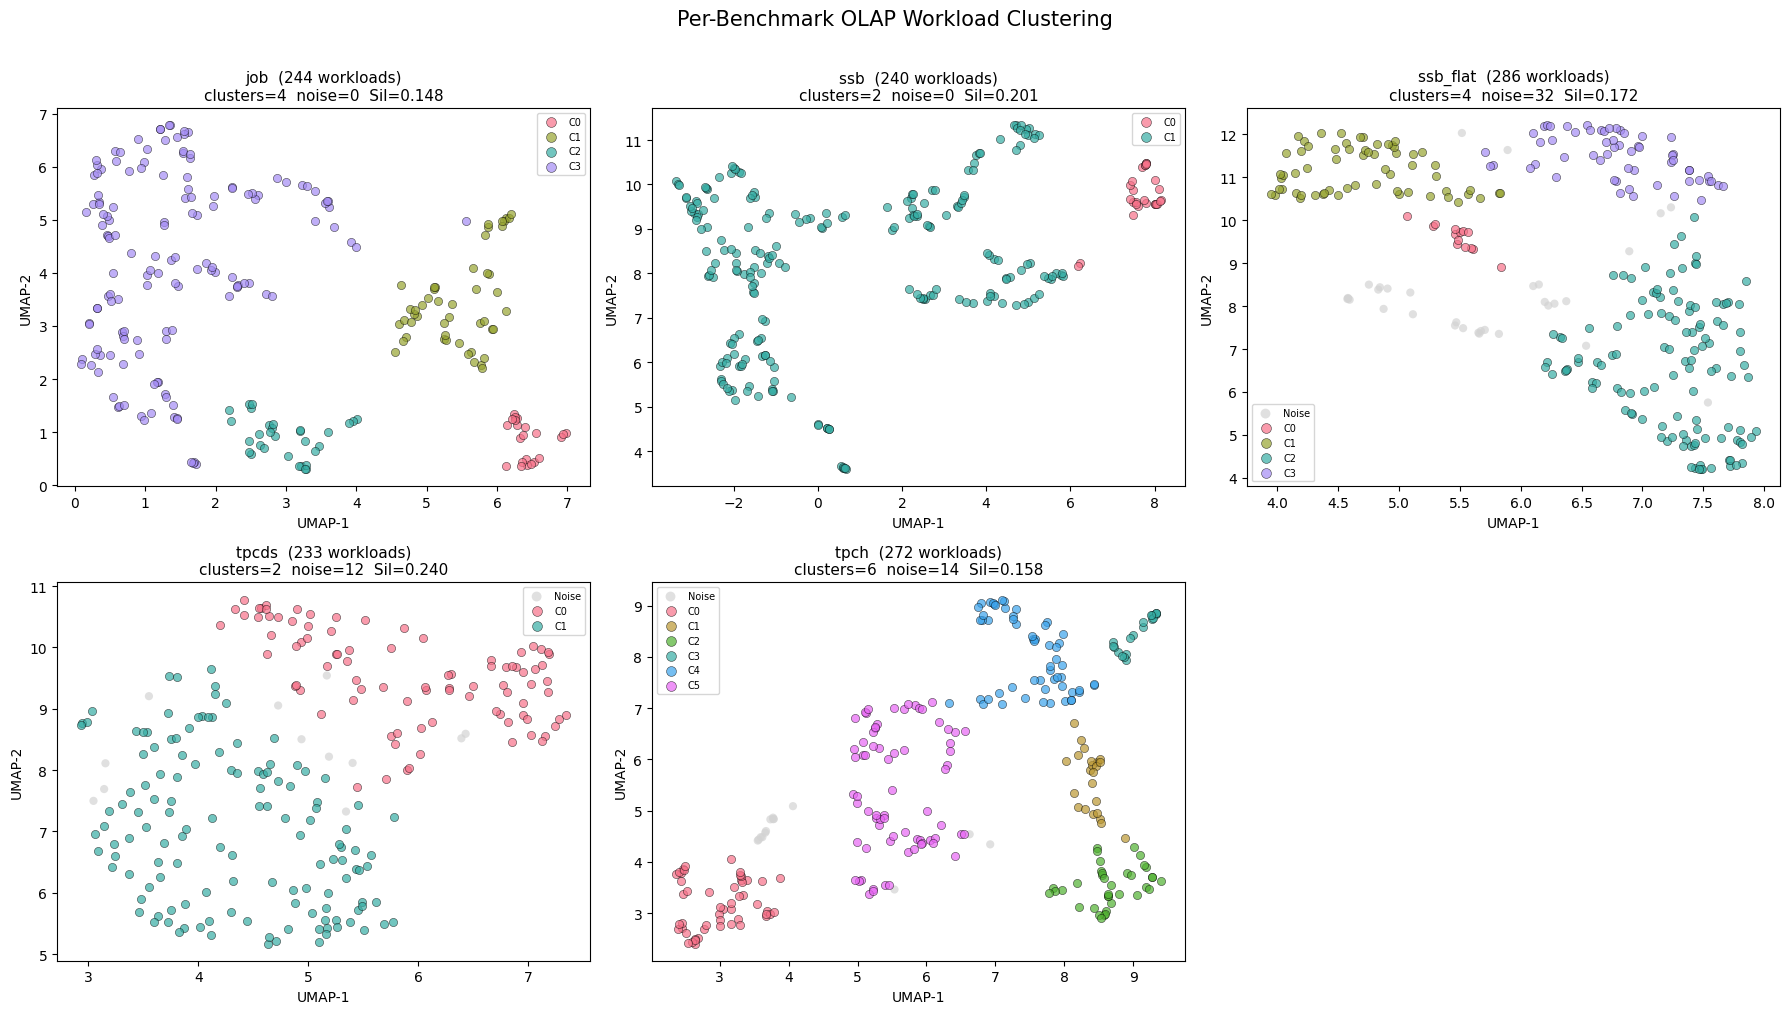

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
# IMPORTANT: Import MinMaxScaler to match the clustering pipeline
from sklearn.preprocessing import MinMaxScaler 

# ── 2-D UMAP scatter plot for each benchmark ──────────────────────────────────
n_bms = len(per_benchmark_results)
ncols = min(3, n_bms)
nrows = (n_bms + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
# Ensure axes is always a flat array, even if there's only 1 subplot
axes = np.array(axes).flatten() if n_bms > 1 else np.array([axes])

for ax_i, (bm, res) in enumerate(sorted(per_benchmark_results.items())):
    ax   = axes[ax_i]
    lbl  = res["labels"]
    fns  = res["filenames"]
    p2d  = res["params"]

    # 2-D projection purely for visualisation
    vis  = umap.UMAP(
        n_neighbors=p2d["n_neighbors"], min_dist=p2d["min_dist"],
        metric=p2d["umap_metric"], n_components=2, random_state=42
    )
    
    # FIX: Use MinMaxScaler so the visual projection perfectly matches 
    # the mathematical space HDBSCAN used for clustering
    X_bm  = MinMaxScaler().fit_transform(embeddings[res["idx"]])
    X2d   = vis.fit_transform(X_bm)

    unique_cls = sorted(set(lbl))
    pal = sns.color_palette("husl", sum(c != -1 for c in unique_cls))
    color_map = {}
    ci = 0
    for c in unique_cls:
        color_map[c] = "lightgrey" if c == -1 else pal[ci]
        if c != -1:
            ci += 1

    for c in unique_cls:
        mask = lbl == c
        label = "Noise" if c == -1 else f"C{c}"
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   c=[color_map[c]], s=35, alpha=0.7,
                   edgecolors='k' if c != -1 else 'none',
                   linewidths=0.4, label=label)

    n_cls   = sum(c != -1 for c in unique_cls)
    n_noise = int(np.sum(lbl == -1))
    
    # ENHANCEMENT: Display the Penalized Silhouette Score if available, 
    # to show the balance between cluster tightness and noise.
    pen_sil = res.get('penalized_sil', res['sil']) 
    
    ax.set_title(
        f"{bm}  ({len(fns)} workloads)\n"
        f"clusters={n_cls}  noise={n_noise}  Sil={pen_sil:.3f}",
        fontsize=11
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.2, loc="best")

# Hide any unused subplots
for ax_j in range(ax_i + 1, len(axes)):
    axes[ax_j].set_visible(False)

plt.suptitle("Per-Benchmark OLAP Workload Clustering", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [52]:
import json

# Build a dictionary of workloads per benchmark per cluster
workload_dict = {}

for bm, res in per_benchmark_results.items():
    bm_key = str(bm)
    workload_dict[bm_key] = {}
    
    for fn, cl in zip(res["filenames"], res["labels"]):
        cluster_key = f"cluster_{cl}" if cl != -1 else "noise"
        if cluster_key not in workload_dict[bm_key]:
            workload_dict[bm_key][cluster_key] = []
        workload_dict[bm_key][cluster_key].append(str(fn))

# Print summary
for bm, clusters in workload_dict.items():
    print(f"\n{bm}:")
    for cluster, wls in sorted(clusters.items()):
        print(f"  {cluster} ({len(wls)} workloads): {wls[:3]}{'...' if len(wls) > 3 else ''}")

# Save to JSON file
output_path = project_root / "workload_clusters3.json"
with open(output_path, "w") as f:
    json.dump(workload_dict, f, indent=2)

print(f"\nSaved to {output_path}")


job:
  cluster_0 (22 workloads): ['job_116.wg', 'job_123.wg', 'job_126.wg']...
  cluster_1 (49 workloads): ['job_100.wg', 'job_103.wg', 'job_106.wg']...
  cluster_2 (31 workloads): ['job_108.wg', 'job_114.wg', 'job_120.wg']...
  cluster_3 (142 workloads): ['job_0.wg', 'job_1.wg', 'job_10.wg']...

ssb:
  cluster_0 (27 workloads): ['ssb_100.wg', 'ssb_11.wg', 'ssb_112.wg']...
  cluster_1 (213 workloads): ['ssb_0.wg', 'ssb_1.wg', 'ssb_10.wg']...

ssb_flat:
  cluster_0 (14 workloads): ['ssb_flat_tiny_111.wg', 'ssb_flat_tiny_137.wg', 'ssb_flat_tiny_154.wg']...
  cluster_1 (62 workloads): ['ssb_flat_tiny_101.wg', 'ssb_flat_tiny_103.wg', 'ssb_flat_tiny_107.wg']...
  cluster_2 (120 workloads): ['ssb_flat_tiny_0.wg', 'ssb_flat_tiny_1.wg', 'ssb_flat_tiny_10.wg']...
  cluster_3 (58 workloads): ['ssb_flat_tiny_11.wg', 'ssb_flat_tiny_115.wg', 'ssb_flat_tiny_118.wg']...
  noise (32 workloads): ['ssb_flat_tiny_108.wg', 'ssb_flat_tiny_123.wg', 'ssb_flat_tiny_138.wg']...

tpcds:
  cluster_0 (89 workloa

In [ ]:
import json
import random
import os

# Your calculated cohesion scores
COHESION_SCORES = {
    "job_cluster_3": 0.792, "job_cluster_1": 0.672, "job_cluster_2": 0.689, "job_cluster_0": 0.658,
    "ssb_cluster_1": 0.851, "ssb_cluster_0": 0.744,
    "ssb_flat_cluster_2": 0.877, "ssb_flat_cluster_1": 0.762, "ssb_flat_noise": 0.821, "ssb_flat_cluster_3": 0.818, "ssb_flat_cluster_0": 0.724,
    "tpcds_cluster_0": 0.738, "tpcds_cluster_1": 0.700,
    "tpch_cluster_3": 0.800, "tpch_cluster_1": 0.756, "tpch_cluster_0": 0.838, "tpch_cluster_2": 0.799, 
    "tpch_cluster_5": 0.827, "tpch_cluster_4": 0.832
}

# The flat directory containing all .wg files
WORKLOAD_BASE_PATH = "/Users/nisith/Desktop/FYP/E2ETune-AI4DB/olap_workloads"

def get_query_count(workload_filename):
    """
    Helper function to get the number of queries in a workload.
    Assumes 1 query per line.
    """
    # Look directly in the base path (no benchmark subfolder)
    filepath = os.path.join(WORKLOAD_BASE_PATH, workload_filename)
    
    try:
        with open(filepath, 'r') as f:
            # Count non-empty lines to get the number of queries
            return sum(1 for line in f if line.strip())
    except FileNotFoundError:
        print(f"Warning: Could not find {filepath}. Pushing to bottom of list.")
        # If the file isn't found, return a massive number so it gets pushed to the bottom of the sort
        return 999999

def generate_size_optimized_samples(input_json, output_json, target_per_bench=12):
    with open(input_json, 'r') as f:
        data = json.load(f)

    sampled_workloads = {}

    for benchmark, clusters in data.items():
        sampled_workloads[benchmark] = {}
        valid_clusters = {k: v for k, v in clusters.items() if k != "noise"}
        
        cluster_weights = {}
        total_weight = 0.0
        
        # 1. Calculate Weights strictly based on Cohesion (Variance)
        for cluster_name in valid_clusters.keys():
            global_name = f"{benchmark}_{cluster_name}"
            cohesion = COHESION_SCORES.get(global_name, 0.75) 
            weight = 1.0 - cohesion
            cluster_weights[cluster_name] = weight
            total_weight += weight

        if total_weight == 0:
            continue

        # 2. Initial Quota Allocation
        quotas = {}
        for cluster_name, weight in cluster_weights.items():
            proportion = weight / total_weight
            quotas[cluster_name] = int(round(target_per_bench * proportion))

        # 3. Size Cap and Redistribution Loop
        unallocated = target_per_bench - sum(quotas.values())
        while True:
            needs_redistribution = False
            for cluster_name in list(quotas.keys()):
                max_size = len(valid_clusters[cluster_name])
                if quotas[cluster_name] > max_size:
                    excess = quotas[cluster_name] - max_size
                    unallocated += excess
                    quotas[cluster_name] = max_size
                    needs_redistribution = True
            
            if unallocated == 0 and not needs_redistribution:
                break
                
            if unallocated > 0:
                eligible_clusters = [c for c in quotas.keys() if quotas[c] < len(valid_clusters[c])]
                if not eligible_clusters:
                    break 
                eligible_clusters.sort(key=lambda c: cluster_weights[c], reverse=True)
                quotas[eligible_clusters[0]] += 1
                unallocated -= 1
            elif unallocated < 0:
                eligible_clusters = [c for c in quotas.keys() if quotas[c] > 0]
                eligible_clusters.sort(key=lambda c: cluster_weights[c])
                quotas[eligible_clusters[0]] -= 1
                unallocated += 1

        # 4. Perform the Size-Optimized Selection
        print(f"\n--- {benchmark.upper()} (Smallest-First Sampling) ---")
        for cluster_name, quota in quotas.items():
            if quota > 0:
                available = valid_clusters[cluster_name]
                
                # Fetch sizes for all available workloads (Notice: removed benchmark from the call)
                workloads_with_sizes = [(w, get_query_count(w)) for w in available]
                
                # FIRST: Randomly shuffle to ensure fair ties
                random.shuffle(workloads_with_sizes)
                
                # SECOND: Sort by size (ascending)
                workloads_with_sizes.sort(key=lambda x: x[1])
                
                # THIRD: Slice the top `quota` workloads (the smallest ones)
                selected = [item[0] for item in workloads_with_sizes[:quota]]
                sampled_workloads[benchmark][cluster_name] = selected
                
                global_name = f"{benchmark}_{cluster_name}"
                coh = COHESION_SCORES.get(global_name, 'N/A')
                picked_sizes = [item[1] for item in workloads_with_sizes[:quota]]
                print(f"  {cluster_name} (Coh: {coh}): Picked {quota} workloads. Query counts: {picked_sizes}")

    # 5. Save output
    with open(output_json, 'w') as f:
        json.dump(sampled_workloads, f, indent=2)
        
    print(f"\n✅ Success! Size-optimized workloads saved to '{output_json}'")

if __name__ == "__main__":
    generate_size_optimized_samples(
        input_json='workload_clusters3.json', 
        output_json='representative_workloads_sampled.json',
        target_per_bench=12
    )


--- JOB (Smallest-First Sampling) ---
  cluster_3 (Coh: 0.792): Picked 2 workloads. Sizes: [999999, 999999]
  cluster_1 (Coh: 0.672): Picked 3 workloads. Sizes: [999999, 999999, 999999]
  cluster_2 (Coh: 0.689): Picked 3 workloads. Sizes: [999999, 999999, 999999]
  cluster_0 (Coh: 0.658): Picked 4 workloads. Sizes: [999999, 999999, 999999, 999999]

--- SSB (Smallest-First Sampling) ---
  cluster_1 (Coh: 0.851): Picked 4 workloads. Sizes: [999999, 999999, 999999, 999999]
  cluster_0 (Coh: 0.744): Picked 8 workloads. Sizes: [999999, 999999, 999999, 999999, 999999, 999999, 999999, 999999]

--- SSB_FLAT (Smallest-First Sampling) ---
  cluster_2 (Coh: 0.877): Picked 2 workloads. Sizes: [999999, 999999]
  cluster_1 (Coh: 0.762): Picked 3 workloads. Sizes: [999999, 999999, 999999]
  cluster_3 (Coh: 0.818): Picked 3 workloads. Sizes: [999999, 999999, 999999]
  cluster_0 (Coh: 0.724): Picked 4 workloads. Sizes: [999999, 999999, 999999, 999999]

--- TPCDS (Smallest-First Sampling) ---
  cluster